# 이미지분류_cnn합성곱 신경망

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

MNIST 손글씨 데이터 불러오기

In [3]:
from keras.datasets import mnist
# 숫자 라벨을 딥러닝에서 사용하는 one-hot encoding 형태로 바꾸는 함수
from keras.utils import to_categorical

2026-03-20 09:20:00.875461: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-20 09:20:00.934446: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-20 09:20:03.010057: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [4]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [5]:
# X_train.shape => (60000, 28, 28): 60000개의 이미지, 각 이미지의 크기 28 * 28
X_train[0].shape

(28, 28)

In [6]:
# 훈련 데이터의 정답 (label)에 어떤 숫자들이 있는지 확인
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

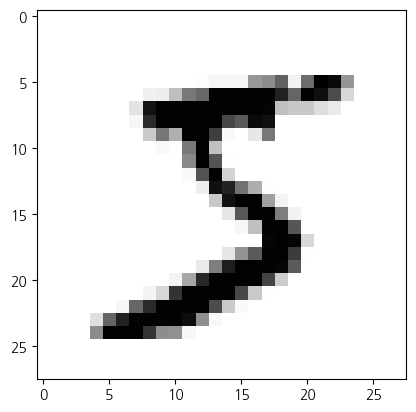

In [7]:
plt.imshow(X_train[0], cmap='Grays')
# cmap='Grays': 흑백으로 표시
plt.show()

In [8]:
# pandas에서 데이터프레임 출력할 때 모든 열 (컬럼) 다 보이게 하는 설정
pd.options.display.max_columns = None

In [9]:
pd.DataFrame(X_train[0])

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,3,18,18,18,126,136,175,26,166,255,247,127,0,0,0,0
6,0,0,0,0,0,0,0,0,30,36,94,154,170,253,253,253,253,253,225,172,253,242,195,64,0,0,0,0
7,0,0,0,0,0,0,0,49,238,253,253,253,253,253,253,253,253,251,93,82,82,56,39,0,0,0,0,0
8,0,0,0,0,0,0,0,18,219,253,253,253,253,253,198,182,247,241,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,80,156,107,253,253,205,11,0,43,154,0,0,0,0,0,0,0,0,0,0


In [10]:
X_train.shape

(60000, 28, 28)

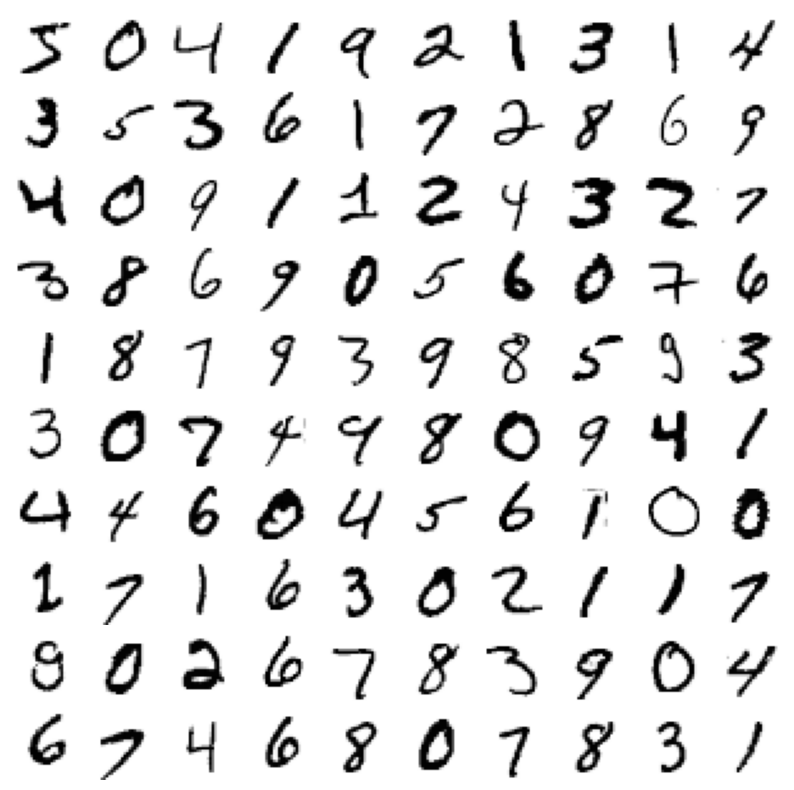

In [11]:
fig, axes = plt.subplots(10, 10, figsize=(10,10))
# plt.subplots(10,10): 그래프를 그릴 칸을 10행 10열로 만들겠다
# fig: 전체 도화지
# axes: 각각의 작은 칸 (10행 10열이니까 axes 안에는 총 100개의 칸)

# 반복문에서 쉽게 쓰기 위해 2차원 배열을 1차원으로 펴는 것
axes = axes.ravel()

for i in range(100):
    axes[i].imshow(X_train[i], cmap='Grays')
    axes[i].axis('off') # 각 칸의 축을 없애 이미지만 깔끔하게
plt.subplots_adjust(wspace=0.1, hspace=0.1) # 가로간격, 세로간격 조절
plt.show()

# 이미지 데이터 훈련을 위한 전처리
* 정규화 = X / 255 => 0\~1 범위로 변환, -1\~1범위로 변환


In [12]:
28*28

784

# MLP로 분석 - 다층 신경망으로 이미지 분석
* 이미지 2차원 => 1차원
* (60000, 28, 28)
* (60000, 784)

In [13]:
X_train.shape

(60000, 28, 28)

In [14]:
mlp_X_train = X_train.reshape(X_train.shape[0], X_train.shape[1]*X_train.shape[2])
mlp_X_train.shape

(60000, 784)

In [15]:
mlp_X_test = X_test.reshape(X_test.shape[0], X_test.shape[1]*X_test.shape[2])
mlp_X_test.shape

(10000, 784)

* 데이터 정규화 0-1

In [16]:
mlp_X_train = mlp_X_train / 255
mlp_X_test = mlp_X_test / 255

In [17]:
mlp_X_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(60000, 784))

In [18]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

# MLP 훈련 예측
* 이미지 분석시 은닉층 노드: 작은 것 => 큰 것 => 작은 것

In [19]:
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [20]:
mlp_X_train.shape[1]

784

In [21]:
mlp_model = Sequential()
mlp_model.add(Input(shape=(mlp_X_train.shape[1], )))
mlp_model.add(Dense(512, activation='relu'))
mlp_model.add(BatchNormalization())
mlp_model.add(Dropout(0.3))
mlp_model.add(Dense(1024, activation='relu'))
mlp_model.add(BatchNormalization())
mlp_model.add(Dropout(0.3))
mlp_model.add(Dense(512, activation='relu'))
mlp_model.add(BatchNormalization())
mlp_model.add(Dropout(0.3))
mlp_model.add(Dense(len(np.unique(y_train)), activation="softmax"))
mlp_model.summary()

I0000 00:00:1773966023.204952   93237 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1347 MB memory:  -> device: 0, name: NVIDIA GeForce MX450, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,465,354 (5.59 MB)

 Trainable params: 1,461,258 (5.57 MB)

 Non-trainable params: 4,096 (16.00 KB)

In [22]:
from sklearn.metrics import classification_report

In [24]:
mlp_model.compile(loss="sparse_categorical_crossentropy", optimizer='adam', metrics=['accuracy'])
early_stop = EarlyStopping(patience=20, restore_best_weights=True)
model_path = "./model/mlp_mnist_model.keras"
model_save = ModelCheckpoint(filepath=model_path, save_best_only=True)
mlp_history = mlp_model.fit(mlp_X_train, y_train,
                       epochs=100,
                        batch_size=64,
                        validation_split=0.25,
                        callbacks=[early_stop, model_save])
mlp_pred = mlp_model.predict(mlp_X_test)

Epoch 1/100


2026-03-20 09:20:33.743090: I external/local_xla/xla/service/service.cc:163] XLA service 0x7d6f44012fc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-20 09:20:33.743189: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2026-03-20 09:20:33.796655: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-20 09:20:34.110145: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92000


 37/704 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5752 - loss: 1.4137

I0000 00:00:1773966037.051495   93329 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9124 - loss: 0.2939 - val_accuracy: 0.9587 - val_loss: 0.1376
Epoch 2/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9535 - loss: 0.1514 - val_accuracy: 0.9670 - val_loss: 0.1101
Epoch 3/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9618 - loss: 0.1215 - val_accuracy: 0.9705 - val_loss: 0.1029
Epoch 4/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9676 - loss: 0.1030 - val_accuracy: 0.9691 - val_loss: 0.1065
Epoch 5/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9702 - loss: 0.0934 - val_accuracy: 0.9738 - val_loss: 0.0877
Epoch 6/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9728 - loss: 0.0863 - val_accuracy: 0.9750 - val_loss: 0.0837
Epoch 7/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9760 - loss: 0.0744 - val_accuracy: 0.9740 - val_loss: 0.0885
Epoch 8/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9767 - loss: 0.0734 - val_accuracy: 0.97

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.99      0.99      1032
           3       0.99      0.98      0.98      1010
           4       0.99      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.99      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.99      0.98       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



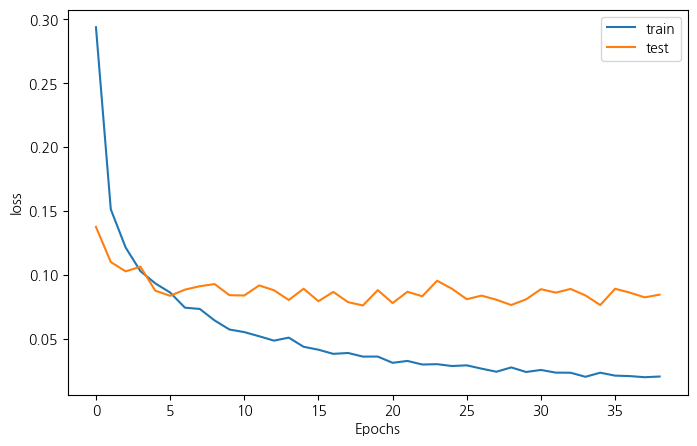

In [26]:
mlp_pred = mlp_pred.argmax(axis=1)
print(classification_report(y_test, mlp_pred))
plt.figure(figsize=(8,5))
plt.plot(mlp_history.history['loss'])
plt.plot(mlp_history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend(['train', 'test'])
plt.show()

In [27]:
512*512

262144

# CNN을 위한 데이터 전처리 3차원 => 4차원
* (전체행개수, 이미지사이즈(행), 이미지사이즈(열), 색레이어수(흑백1, 컬러3))
* 데이터 타입을 float32로 변환

In [28]:
X_train.shape

(60000, 28, 28)

In [29]:
X_train[0].dtype

dtype('uint8')

In [30]:
(X_train[0]/255).dtype

dtype('float64')

In [31]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)
X_train.shape

(60000, 28, 28, 1)

In [32]:
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 1)
X_test.shape

(10000, 28, 28, 1)

In [33]:
X_train = X_train / 255
X_test = X_test / 255

In [34]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [35]:
X_train.shape

(60000, 28, 28, 1)

In [36]:
X_train.dtype

dtype('float32')

# CNN 합성곱 네트워크를 위한 모델 생성
* Conv2D: 이미지의 특징 찾는 레이어
* MaxPooling2D: 이미지의 크기 줄임
* Flatten: 1차원으로 차원 축소
* Dense
    * Dense(10): 10개의 출력 노드
        * MNIST라면 0 1 2 3 4 5 6 7 8 9 각 숫자의 확률 계산
* Dropout: 과적합 방지하기 위함 (훈련 중에 일부 뉴런을 랜덤하게 끔)

In [37]:
from keras.layers import Conv2D, MaxPooling2D, Flatten

In [38]:
X_train.shape[1:]

(28, 28, 1)

In [39]:
cnn_model = Sequential()
cnn_model.add(Input(shape=X_train.shape[1:]))
# Conv2D(32,(3,3)): 3 x 3 필터 32개로 이미지 특징 찾음
cnn_model.add(Conv2D(32, (3,3), padding='same', activation='relu'))
cnn_model.add(BatchNormalization())
cnn_model.add(Dropout(0.3))
cnn_model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D((2,2)))
cnn_model.add(Dropout(0.3))
cnn_model.add(Conv2D(32, (3,3), padding='same', activation='relu'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D((2,2)))
cnn_model.add(Dropout(0.3))
cnn_model.add(Flatten())
cnn_model.add(Dense(len(np.unique(y_train)), activation='softmax'))
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │        15,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,482 (208.91 KB)

 Trainable params: 53,226 (207.91 KB)

 Non-trainable params: 256 (1.00 KB)

In [40]:
cnn_model.compile(loss="sparse_categorical_crossentropy", optimizer='adam', metrics=['accuracy'])
early_stop = EarlyStopping(patience=20, restore_best_weights=True)
model_path = "./model/cnn_mnist_model.keras"
model_save = ModelCheckpoint(filepath=model_path, save_best_only=True)
cnn_history = cnn_model.fit(X_train, y_train,
                       epochs=100,
                        batch_size=64,
                        validation_split=0.25,
                        callbacks=[early_stop, model_save])
cnn_pred = cnn_model.predict(X_test)
cnn_pred = cnn_pred.argmax(axis=1)
print(classification_report(y_test, cnn_pred))
plt.figure(figsize=(8,5))
plt.plot(cnn_history.history['loss'])
plt.plot(cnn_history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend(['train', 'test'])
plt.show()

Epoch 1/100


2026-03-20 09:26:07.632825: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[64,32,28,28]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,1,28,28]{3,2,1,0}, f32[32,1,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-20 09:26:07.738966: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[64,64,28,28]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,32,28,28]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cud

702/704 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8048 - loss: 0.6963

2026-03-20 09:26:33.620019: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[8,64,28,28]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,32,28,28]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-20 09:26:33.892966: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[8,32,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,64,14,14]{3,2,1,0}, f32[32,64,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn

704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8051 - loss: 0.6952

2026-03-20 09:26:45.471351: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[64,32,28,28]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,1,28,28]{3,2,1,0}, f32[32,1,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-20 09:26:45.528579: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[64,64,28,28]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,32,28,28]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cud

704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - accuracy: 0.9086 - loss: 0.3059 - val_accuracy: 0.9746 - val_loss: 0.0812
Epoch 2/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.9709 - loss: 0.0954 - val_accuracy: 0.9827 - val_loss: 0.0563
Epoch 3/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.9783 - loss: 0.0695 - val_accuracy: 0.9855 - val_loss: 0.0485
Epoch 4/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.9814 - loss: 0.0595 - val_accuracy: 0.9853 - val_loss: 0.0475
Epoch 5/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.9831 - loss: 0.0556 - val_accuracy: 0.9875 - val_loss: 0.0407
Epoch 6/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 36ms/step - accuracy: 0.9831 - loss: 0.0520 - val_accuracy: 0.9847 - val_loss: 0.0560
Epoch 7/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.9856 - loss: 0.0451 - val_accuracy: 0.9868 - val_loss: 0.0435
Epoch 8/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.9861 - loss: 0.0433 - val_